# Notebook 01 — Dataset Preparation for AMP Discovery

This notebook curates a raw Peptipedia-derived sequence dataset to produce a clean, deduplicated, and redundancy-reduced input for downstream analysis and modelling. The main steps are: loading and inspecting raw data, filtering by sequence validity and length, labelling sequences, exporting to FASTA for clustering with MMseqs2, and generating the final preprocessed dataset from representative cluster sequences.

**Expected input:** a CSV file with at least:

- `sequence`: peptide sequence string
- `Antimicrobial`: binary annotation (1 = AMP, 0 = non-AMP)

**Main outputs:**

- `results/peptipedia_amp_dataset.fasta` — filtered sequences in FASTA format
- `results/preprocessed_dataset.csv` — final deduplicated, redundancy-reduced labelled dataset

## 1. Imports and configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

## 2. Load dataset

This step loads the raw dataset from the Peptipedia-derived CSV file.

In [ ]:
DATASET_PATH = "../raw_dataset/pivoted_sequences.csv"

df = pd.read_csv(DATASET_PATH)

print(df.shape)
df.head()

(86477, 214)


,sequence,Anti_HIV,Therapeutic,Anti_nematode,Anti_coronaviridae,Anti_feline_coronavirus,Enzyme_inhibitor,Anti_west_nile_virus,Anti_junin_virus,Anti_iridoviridae,...,Anti_human_coronavirus,Anti_human_parainfluenza_virus,Anti_puumala_virus,Anti_amnesic,Cytokine,Anti_hendra_virus,Potentiator,Neuropeptide,Anti_white_spot_syndrome_virus,Anti_herpesviridae
0,MFTLKKTLLLLFFIGTISLSLCEQERDADEDEGEALEEVKRGLWDT...,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,QMIVIELGTNPLK,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,PTSRGNNRRPQTRGMVEECCFRSCDLNLLEQYCAKPAKSERDVSAT...,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,RCICTLGVC,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,MNFKYIVAVSFLIASGYARSVRNDEQSLSQRDVLEEESPREIRGIG...,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(df.shape)

print(df.columns)

df.info()

(86477, 214)
Index(['sequence', 'Anti_HIV', 'Therapeutic', 'Anti_nematode',
       'Anti_coronaviridae', 'Anti_feline_coronavirus', 'Enzyme_inhibitor',
       'Anti_west_nile_virus', 'Anti_junin_virus', 'Anti_iridoviridae',
       ...
       'Anti_human_coronavirus', 'Anti_human_parainfluenza_virus',
       'Anti_puumala_virus', 'Anti_amnesic', 'Cytokine', 'Anti_hendra_virus',
       'Potentiator', 'Neuropeptide', 'Anti_white_spot_syndrome_virus',
       'Anti_herpesviridae'],
      dtype='str', length=214)
<class 'pandas.DataFrame'>
RangeIndex: 86477 entries, 0 to 86476
Columns: 214 entries, sequence to Anti_herpesviridae
dtypes: int64(213), str(1)
memory usage: 144.1 MB


In [ ]:
df["Antimicrobial"].value_counts(dropna=False)

Antimicrobial
0    52067
1    34410
Name: count, dtype: int64

## 3. Deduplication

This step removed exact sequences duplicates based on the `sequence` column.

In [ ]:
df = df.drop_duplicates(subset="sequence")

print(df.shape)

(86477, 214)


## 4. Canonical sequence filtering

In this step, sequences containing non-standard amino acids are removed.

In [ ]:
CANONICAL_AA = set("ACDEFGHIKLMNPQRSTVWY")

In [ ]:
def is_canonical(seq: str) -> bool:
    return set(seq).issubset(CANONICAL_AA)

In [ ]:
df = df[
    df["sequence"].apply(is_canonical)
]

## 5. Length filtering

This section retain sequences within the range `[MIN_LEN, MAX_LEN]`.

In [ ]:
MIN_LEN = 5
MAX_LEN = 60

In [ ]:
df["length"] = df["sequence"].str.len()

df = df[
    (df["length"] >= MIN_LEN)
    &
    (df["length"] <= MAX_LEN)
]

<Axes: >

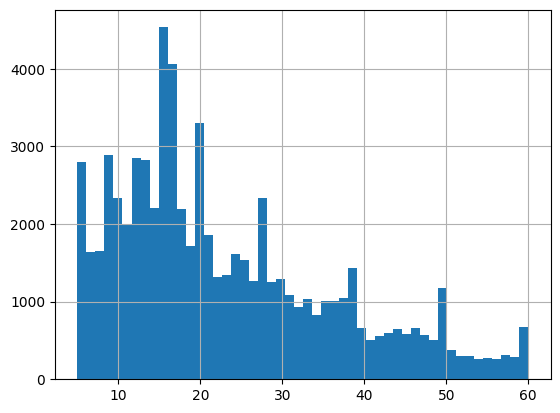

In [ ]:
df["length"].hist(bins=50)

## 6. Label assignment

This step assigns the label for sequences. The label is is derived from the `Antimicrobial` column. When sequences have value `1` in `Antimicrobial` column, the label assigned is `1` (AMP). All other sequences are labelled with `0` (non-AMP).

In [ ]:
df["label"] = (
    df["Antimicrobial"] == 1
).astype(int)

In [ ]:
df["label"].value_counts()

label
0    40115
1    28621
Name: count, dtype: int64

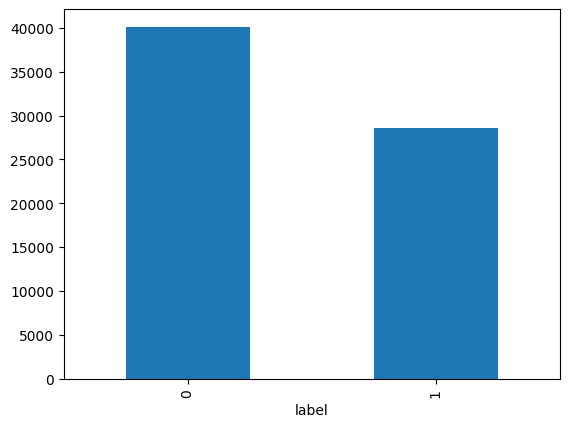

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot.bar()
plt.show()

## 7. FASTA export for redundancy reduction

In this section, the filtered and labelled dataset is exported to FASTA format.
This file is subsequently processed with **MMseqs2** (external step, not shown here) to cluster sequences at a sequence-identity threshold and retain only one representative per cluster.

In [ ]:
with open("../results/peptipedia_amp_dataset.fasta", "w") as f:

    for idx, row in df.iterrows():

        f.write(
            f">{idx}\n"
            f"{row['sequence']}\n"
        )

## 8. Load MMseqs2 representative sequences

After MMseqs2 clustering (run externally), the representative sequence FASTA is loaded and parsed using `BioPython`.

In [ ]:
from Bio import SeqIO

In [ ]:
data_seqs = []

for record in SeqIO.parse("../results/mmseqs_out_rep_seq.fasta", "fasta"):
    row = {
        "id": record.id,
        "sequence" : str(record.seq)
    }

    data_seqs.append(row)

df_rep = pd.DataFrame(data_seqs)
df_rep.shape


(47175, 2)

In [ ]:
df_rep.head()

,id,sequence
0,20589,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL
1,20590,LHYNWIDCCHYGVSDCC
2,20592,WDEDGAKRIPVDVSE
3,20594,RQIKKAFRKMA
4,20595,MKIKTGARILALSALTTMMFSASALAK


## 9. Merge labels onto representative sequences

In this step, the representative sequence identifiers are merged with the original filtered dataset to recover the AMP/non-AMP labels.

In [ ]:
df = df[["sequence", "label"]]
df.shape

(68736, 2)

In [ ]:
df_rep = df_rep.merge(on="sequence", right=df)
df_rep.head()

,id,sequence,label
0,20589,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,1
1,20590,LHYNWIDCCHYGVSDCC,0
2,20592,WDEDGAKRIPVDVSE,0
3,20594,RQIKKAFRKMA,1
4,20595,MKIKTGARILALSALTTMMFSASALAK,0


In [ ]:
df_rep.shape

(47175, 3)

In [ ]:
df_rep["label"].value_counts()

label
0    30661
1    16514
Name: count, dtype: int64

## 10. Export preprocessed dataset

Finally, the final dataset that contains only canonical, length-filtered, deduplicated, and redundancy-reduced sequences with binary labels is saved in a CSV file.

In [ ]:
df_rep[["sequence", "label"]].to_csv("../results/preprocessed_dataset.csv", index=False)